---
title: Clasificación de Himenópteros (Hormigas vs Abejas)
subject: Aprendizaje Profundo
subtitle: Transfer Learning
short_title: Transfer Learning
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap2/070_Transfer_Learning.ipynb)

**Objetivo**: En este cuadernillo aprenderás a aplicar Transfer Learning (aprendizaje por transferencia) con PyTorch para clasificar imágenes de dos clases: hormigas (*ants*) y abejas (*bees*).

Basado en el tutorial oficial de PyTorch *Transfer Learning for Computer Vision* y en Géron (2023) *Hands-On Machine Learning*.

<font color="teal">**Tip**. El entrenamiento con imágenes puede ser lento sin acelerador de hardware. Si estás en Colab, ve a **Entorno de ejecución > Cambiar tipo de entorno de ejecución** y selecciona **GPU T4**.</font>

## 1. Preparativos

Verificamos las versiones de las librerías principales y el dispositivo disponible (CPU o GPU).

In [3]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.9 MB/s eta 0:00:00


In [4]:
import sys
import torch
import torchvision
import torchmetrics

print(f"Python      : {sys.version}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Torchmetrics: {torchmetrics.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo : {device}")
if device.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    print("No se detectó GPU. El entrenamiento usará CPU (más lento).")

Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
Torchmetrics: 1.9.0

Dispositivo : cuda
GPU         : Tesla T4


## 2. Descarga y exploración del dataset

Usaremos el **dataset Hymenoptera** del tutorial oficial de PyTorch. Contiene imágenes de dos clases:

| Clase | Imágenes de entrenamiento | Imágenes de validación |
|-------|--------------------------|------------------------|
| Hormigas (*ants*) | 124 | 70 |
| Abejas (*bees*)   | 121 | 83 |

El dataset ya viene dividido en `train/` y `val/`. Usaremos **la mitad del conjunto de validación como conjunto de prueba**.

### 2.1 Descarga automática del dataset

In [5]:
from pathlib import Path
import urllib.request
import zipfile

def download_hymenoptera_dataset():
    data_dir = Path("datasets")
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = data_dir / "hymenoptera_data.zip"
    data_dir.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("Descargando...", end="")
        urllib.request.urlretrieve(url, zip_path)
        print(" Listo.")
    unzipped_dir = data_dir / "hymenoptera_data"
    if not unzipped_dir.exists():
        print("Extrayendo...", end="")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)
        print(" Listo.")
    return unzipped_dir

hymenoptera_dir = download_hymenoptera_dataset()
print(f"\nDataset disponible en: {hymenoptera_dir}")

Descargando... Listo.
Extrayendo... Listo.

Dataset disponible en: datasets/hymenoptera_data


### 2.2 Visualización de ejemplos

Veamos una imagen de cada clase para familiarizarnos con los datos.

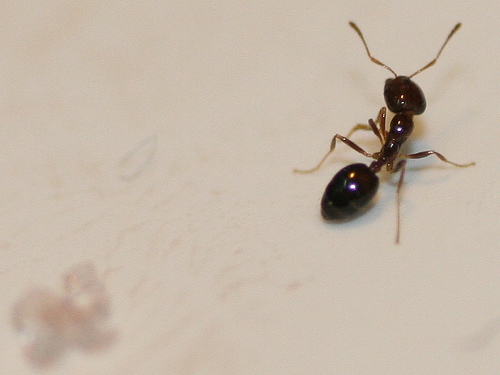

In [6]:
import PIL.Image

PIL.Image.open(hymenoptera_dir / "train" / "ants" / "560966032_988f4d7bc4.jpg")

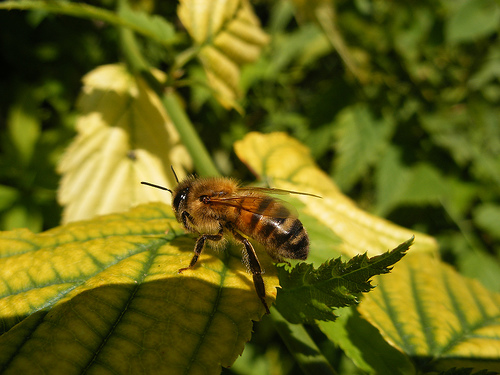

In [7]:
PIL.Image.open(hymenoptera_dir / "train" / "bees" / "760568592_45a52c847f.jpg")

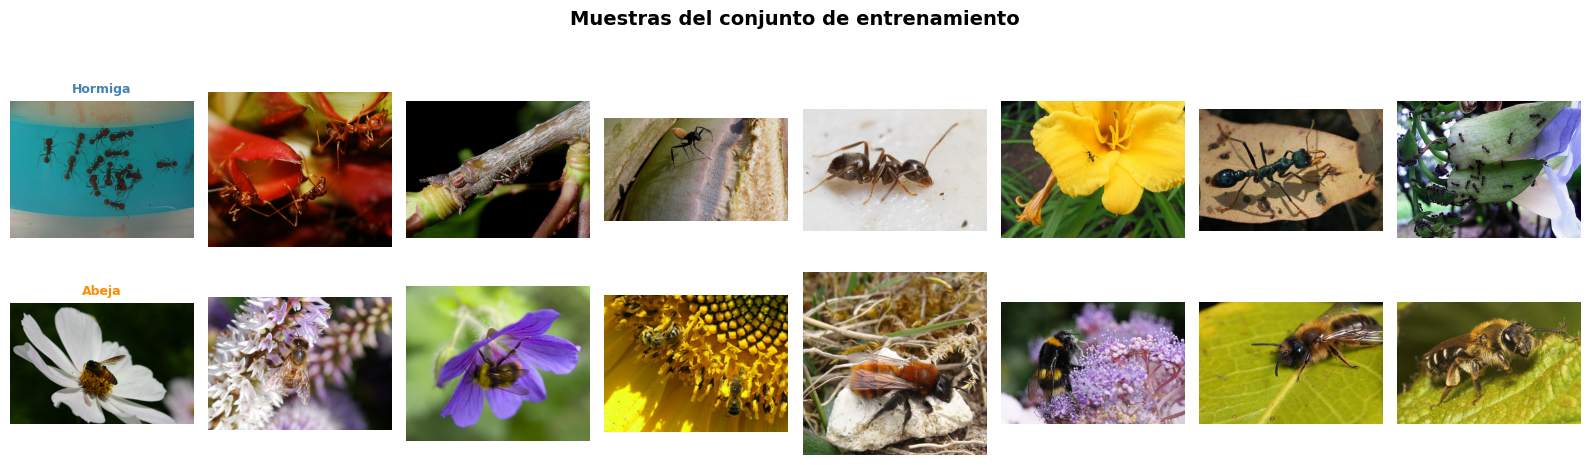

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Muestras del conjunto de entrenamiento", fontsize=14, fontweight="bold")

ant_files = list((hymenoptera_dir / "train" / "ants").glob("*.jpg"))
bee_files = list((hymenoptera_dir / "train" / "bees").glob("*.jpg"))

sample_ants = random.sample(ant_files, 8)
sample_bees = random.sample(bee_files, 8)

for i, ax in enumerate(axes[0]):
    img = mpimg.imread(sample_ants[i])
    ax.imshow(img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Hormiga", fontsize=9, color="steelblue", fontweight="bold")

for i, ax in enumerate(axes[1]):
    img = mpimg.imread(sample_bees[i])
    ax.imshow(img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Abeja", fontsize=9, color="darkorange", fontweight="bold")

plt.tight_layout()
plt.show()

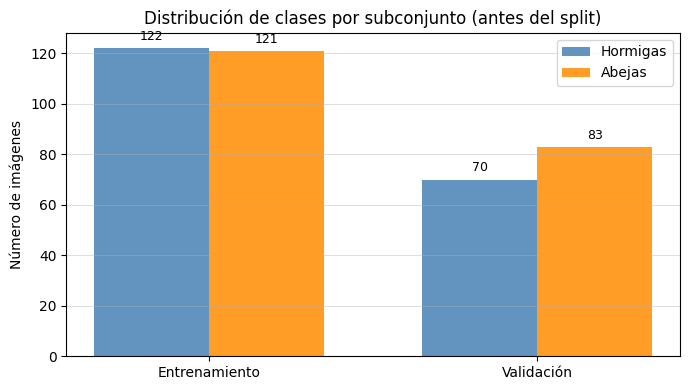

In [9]:
import numpy as np

splits = ["train", "val"]
classes = ["ants", "bees"]
labels_es = ["Hormigas", "Abejas"]
colors = ["steelblue", "darkorange"]

counts = {
    cls: [len(list((hymenoptera_dir / s / cls).glob("*.jpg"))) for s in splits]
    for cls in classes
}

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, (cls, label, color) in enumerate(zip(classes, labels_es, colors)):
    bars = ax.bar(x + (i - 0.5) * width, counts[cls], width,
                  label=label, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Entrenamiento", "Validación"])
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases por subconjunto (antes del split)")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio 1.** Comprensión del dataset y el problema</font>

<font color="green">Responde las siguientes preguntas antes de continuar:</font>

1. El dataset de entrenamiento tiene aproximadamente 245 imágenes en total (124 hormigas + 121 abejas). ¿Por qué entrenar una CNN desde cero con tan pocas imágenes sería problemático?

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Con apenas ~245 imágenes de entrenamiento, una CNN desde cero sufriría sobreajuste severo: aprendería los detalles específicos de esas pocas imágenes (texturas de fondo, iluminación, ángulos particulares) en lugar de aprender características generales que discriminen hormigas de abejas. Además, el gradiente de descenso necesita muchos ejemplos para estimar correctamente los millones de parámetros de una red profunda. El resultado sería una alta exactitud en entrenamiento pero una precisión muy baja en datos nuevos.
</p>
</details>

---

<font color="green">2. El modelo ConvNeXt fue preentrenado en **ImageNet**, un dataset con 1.2 millones de imágenes y 1 000 clases. ¿Por qué sus características aprendidas son útiles para clasificar hormigas y abejas, aunque ninguna de esas 1 000 clases sea exactamente "hormiga" ni "abeja"?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Las capas convolucionales de una red profunda aprenden jerarquías de características visuales reutilizables: bordes y gradientes en las primeras capas, texturas y formas en las intermedias, y partes de objetos en las más profundas. Estas representaciones son genéricas para cualquier imagen natural, independientemente de la clase final. Al clasificar insectos, la red puede reutilizar detectores de texturas (alas, exoesqueletos, patrones de color) y detectores de formas (segmentos corporales, antenas) que aprendió de millones de imágenes variadas. De hecho, ImageNet sí incluye clases relacionadas como "grasshopper" o "ladybug", lo que hace el transfer aún más efectivo.
</p>
</details>

---

<font color="green">3. ¿Por qué dividimos el conjunto de validación original en dos mitades (validación y prueba) en lugar de usar directamente el conjunto de validación como conjunto de prueba?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El conjunto de validación se usa durante el entrenamiento para tomar decisiones: seleccionar hiperparámetros, elegir cuántas épocas entrenar, comparar arquitecturas, etc. Si también lo usamos como conjunto de prueba final, el modelo habrá "visto" indirectamente esos datos a través de las decisiones de diseño tomadas basándonos en ellos, y nuestra estimación final de desempeño será optimistamente sesgada. El conjunto de prueba debe permanecer completamente oculto hasta la evaluación final para obtener una estimación honesta de cómo el modelo generaliza a datos nunca vistos.
</p>
</details>

## 3. Preparación del pipeline de datos

Aplicamos las mismas transformaciones que usa el tutorial oficial de PyTorch. Las imágenes se normalizan con la **media y desviación estándar de ImageNet** `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])` porque el modelo preentrenado fue entrenado con esos valores.

Para el conjunto de entrenamiento se aplica **data augmentation**: recorte aleatorio y volteo horizontal, para aumentar artificialmente la diversidad sin recolectar más imágenes.

In [10]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn

# Transformaciones para entrenamiento (con data augmentation)
train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para validación y prueba (sin augmentation)
valid_test_transforms = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set      = ImageFolder(hymenoptera_dir / "train", train_transforms)
valid_test_set = ImageFolder(hymenoptera_dir / "val",   valid_test_transforms)

# Dividimos el conjunto val original en validación (50%) y prueba (50%)
torch.manual_seed(42)
valid_set, test_set = torch.utils.data.random_split(valid_test_set, [0.5, 0.5])

class_names = train_set.classes
print(f"Clases         : {class_names}")
print(f"Entrenamiento  : {len(train_set):>4} imágenes")
print(f"Validación     : {len(valid_set):>4} imágenes")
print(f"Prueba         : {len(test_set):>4} imágenes")

Clases         : ['ants', 'bees']
Entrenamiento  :  244 imágenes
Validación     :   77 imágenes
Prueba         :   76 imágenes


In [11]:
batch_size   = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader  = DataLoader(test_set,  batch_size=batch_size)

# Verificar forma de un batch
X_batch, y_batch = next(iter(train_loader))
print(f"Forma del batch de imágenes  : {X_batch.shape}")
print(f"Forma del batch de etiquetas : {y_batch.shape}")
print(f"Dtype de las imágenes        : {X_batch.dtype}")

Forma del batch de imágenes  : torch.Size([32, 3, 224, 224])
Forma del batch de etiquetas : torch.Size([32])
Dtype de las imágenes        : torch.float32


### 3.1 Visualización de imágenes preprocesadas

Visualizamos cómo lucen las imágenes **después** de las transformaciones. Para visualizarlas correctamente debemos **deshacer la normalización**.

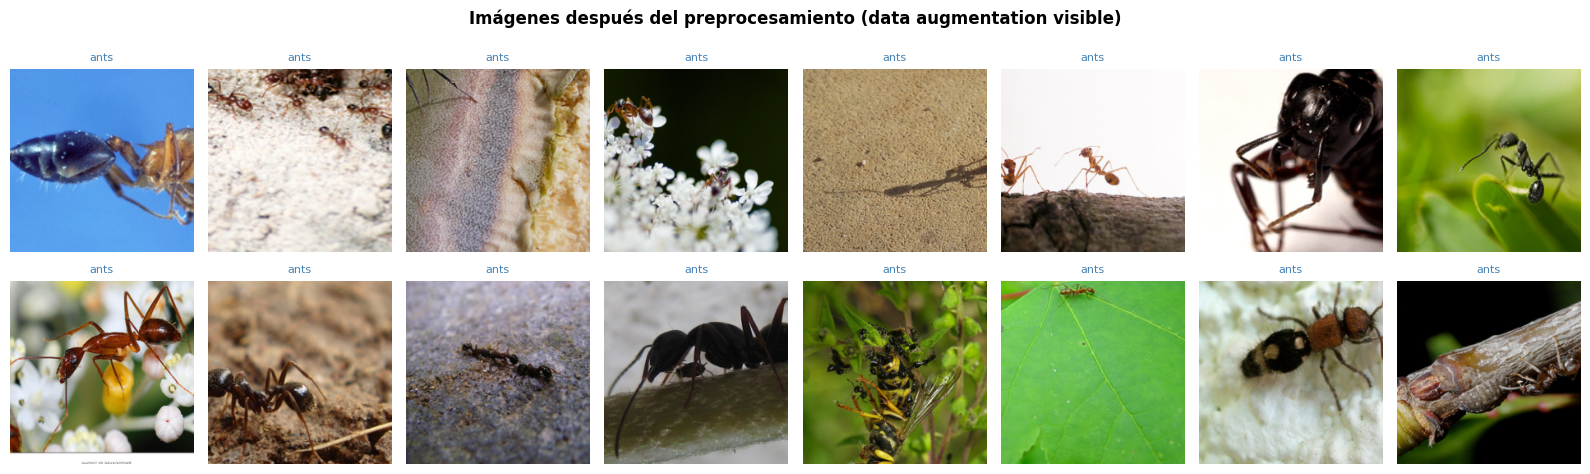

In [12]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Deshace la normalización ImageNet para visualización."""
    return (tensor * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Imágenes después del preprocesamiento (data augmentation visible)",
             fontsize=12, fontweight="bold")

for i, ax in enumerate(axes.flat):
    idx = i % len(train_set)
    img_tensor, label = train_set[idx]
    img_np = denormalize(img_tensor).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.axis("off")
    color = "steelblue" if label == 0 else "darkorange"
    ax.set_title(class_names[label], fontsize=8, color=color)

plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio 2.** El pipeline de datos y el preprocesamiento</font>

Responde las siguientes preguntas:

<font color="green">1. Las transformaciones de validación y prueba usan `Resize(232)` seguido de `CenterCrop(224)`, mientras que el entrenamiento usa `RandomResizedCrop(224)` directamente. ¿Por qué se usa un enfoque diferente para validación/prueba? ¿Qué problema generaría aplicar `RandomResizedCrop` en validación?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
En validación y prueba necesitamos evaluaciones reproducibles y consistentes: la misma imagen debe producir siempre la misma predicción. RandomResizedCrop aplica recortes aleatorios, por lo que una misma imagen daría métricas diferentes cada vez que se evalúa, haciendo imposible comparar resultados entre épocas de forma confiable. El Resize+CenterCrop es determinista: siempre extrae el centro de la imagen, que generalmente contiene el objeto principal. En entrenamiento, la aleatoriedad es deseable porque genera variaciones artificiales que ayudan a regularizar el modelo.
</p>
</details>

---

<font color="green">2. La normalización usa `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`, que son los valores calculados sobre todo ImageNet. ¿Por qué es importante usar **estos valores específicos** y no recalcularlos sobre el dataset Hymenoptera?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El modelo ConvNeXt aprendió sus pesos asumiendo que las imágenes de entrada estaban normalizadas con la distribución de ImageNet. Si usamos una normalización diferente (por ejemplo, la media y std del dataset de hormigas/abejas), los valores que llegan a las primeras capas del modelo serán distintos a los que el modelo "espera", y los filtros preentrenados funcionarán de manera subóptima. Es como cambiar las unidades de medida a mitad de un experimento: las relaciones aprendidas ya no son válidas. Usar los mismos valores de normalización garantiza que las activaciones de las capas preentrenadas sean coherentes con lo que el modelo aprendió.
</p>
</details>


## 4. Construcción del modelo con Transfer Learning

Usamos **ConvNeXt Base**, una arquitectura moderna preentrenada en ImageNet. El proceso de transfer learning tiene dos etapas:

1. **Cargar el modelo preentrenado** con sus pesos de ImageNet.
2. **Reemplazar la cabeza** (última capa `Linear`) por una nueva adaptada a nuestro número de clases (2).
3. **Congelar los pesos** del cuerpo preentrenado para que solo se entrene la nueva cabeza.

### 4.1 Carga del modelo preentrenado

In [13]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model   = torchvision.models.convnext_base(weights=weights).to(device)

print("Arquitectura del clasificador original:")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:05<00:00, 61.6MB/s]


Arquitectura del clasificador original:
Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)


### 4.2 Reemplazo de la cabeza de clasificación

La capa final del clasificador tiene 1 000 salidas (una por clase de ImageNet). La reemplazamos por una capa con **2 salidas** (hormiga y abeja).

> **Nota**: Usamos 2 salidas con `CrossEntropyLoss` en lugar de 1 salida con `BCEWithLogitsLoss`. Ambos enfoques son válidos para clasificación binaria, pero `CrossEntropyLoss` generaliza más fácilmente si en el futuro se quieren agregar más clases.

In [14]:
# Reemplazar la capa lineal final (1000 clases → 2 clases)
model.classifier[2] = nn.Linear(1024, 2).to(device)

print("Arquitectura del clasificador modificado:")
print(model.classifier)

Arquitectura del clasificador modificado:
Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=2, bias=True)
)


### 4.3 Congelamiento de pesos

Congelamos todos los parámetros del modelo y luego **descongelamos solo la cabeza** (`model.classifier`). Esto permite que el cuerpo preentrenado actúe como extractor de características fijo.

In [15]:
# Congelar TODOS los parámetros
for param in model.parameters():
    param.requires_grad = False

# Descongelar solo la cabeza de clasificación
for param in model.classifier.parameters():
    param.requires_grad = True

# Verificar cuántos parámetros son entrenables
total_params      = sum(p.numel() for p in model.parameters())
trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params     = total_params - trainable_params

print(f"Parámetros totales        : {total_params:>12,}")
print(f"Parámetros entrenables    : {trainable_params:>12,}  ({trainable_params/total_params*100:.2f}%)")
print(f"Parámetros congelados     : {frozen_params:>12,}  ({frozen_params/total_params*100:.2f}%)")

Parámetros totales        :   87,568,514
Parámetros entrenables    :        4,098  (0.00%)
Parámetros congelados     :   87,564,416  (100.00%)


---

### <font color="blue">**Ejercicio 3.** Arquitectura y estrategia de Transfer Learning</font>

Responde las siguientes preguntas:

<font color="green">1. Observa el porcentaje de parámetros entrenables vs congelados. ¿Qué ventaja práctica (en términos de tiempo de entrenamiento y riesgo de sobreajuste) tiene el hecho de que solo un pequeño porcentaje de los parámetros sea entrenable?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Entrenar solo la cabeza tiene dos ventajas principales: (1) <strong>Velocidad</strong>: como los gradientes no necesitan propagarse por todo el modelo (solo por la cabeza), cada paso de entrenamiento es mucho más rápido. (2) <strong>Regularización implícita</strong>: con solo ~2000 parámetros entrenables y ~245 imágenes, la relación datos/parámetros es favorable, reduciendo drásticamente el sobreajuste. Entrenar los 88 millones de parámetros totales con tan pocos datos casi con certeza llevaría a sobreajuste extremo.
</p>
</details>

---

<font color="green">2. ¿Por qué la nueva capa lineal (la cabeza reemplazada) NO debe congelarse, aunque el resto del modelo sí lo está?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
La capa lineal reemplazada se inicializa con pesos aleatorios (no tiene conocimiento previo sobre hormigas o abejas). Si se congela, sus pesos aleatorios permanecerán fijos y el modelo simplemente producirá clasificaciones aleatorias para siempre. Es la única parte del modelo que necesita aprender desde cero a mapear las ricas representaciones del cuerpo preentrenado a las dos clases específicas de nuestro problema. Las capas del cuerpo, en cambio, ya tienen representaciones útiles que no queremos destruir al inicio del entrenamiento.
</p>
</details>


## 5. Función de entrenamiento

Definimos una función genérica `train()` que entrena el modelo durante múltiples épocas, registrando la pérdida y exactitud en entrenamiento y validación.

In [16]:
import torchmetrics

def train_one_epoch(model, optimizer, loss_fn, metric, loader):
    model.train()
    metric.reset()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
        metric.update(logits, y_batch)
    return total_loss / len(loader.dataset), metric.compute().item()


@torch.no_grad()
def evaluate(model, loss_fn, metric, loader):
    model.eval()
    metric.reset()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        total_loss += loss.item() * len(X_batch)
        metric.update(logits, y_batch)
    return total_loss / len(loader.dataset), metric.compute().item()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc  = train_one_epoch(model, optimizer, loss_fn, metric, train_loader)
        vl_loss, vl_acc  = evaluate(model, loss_fn, metric, valid_loader)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        print(f"Época {epoch:2d}/{n_epochs}  "
              f"| Pérdida entren.: {tr_loss:.4f}  Exactitud entren.: {tr_acc:.4f}  "
              f"| Pérdida val.: {vl_loss:.4f}  Exactitud val.: {vl_acc:.4f}")
    return history


@torch.no_grad()
def evaluate_final(model, loader, metric):
    model.eval()
    metric.reset()
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        metric.update(logits, y_batch)
    acc = metric.compute().item()
    print(f"Exactitud en prueba: {acc:.4f}  ({acc*100:.2f}%)")
    return acc

print("Funciones de entrenamiento definidas correctamente.")

Funciones de entrenamiento definidas correctamente.


## 6. Entrenamiento: solo la cabeza (Feature Extraction)

En la primera fase, entrenamos **solo la cabeza** del modelo durante 5 épocas. El cuerpo del ConvNeXt actúa como extractor de características fijo.

In [17]:
n_epochs  = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
xentropy  = nn.CrossEntropyLoss()
accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)

print("=" * 80)
print(" Fase 1: Entrenamiento de la cabeza (Feature Extraction)")
print("=" * 80)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

 Fase 1: Entrenamiento de la cabeza (Feature Extraction)
Época  1/5  | Pérdida entren.: 0.4938  Exactitud entren.: 0.8730  | Pérdida val.: 0.2457  Exactitud val.: 1.0000
Época  2/5  | Pérdida entren.: 0.2195  Exactitud entren.: 0.9795  | Pérdida val.: 0.1023  Exactitud val.: 1.0000
Época  3/5  | Pérdida entren.: 0.1236  Exactitud entren.: 0.9795  | Pérdida val.: 0.0565  Exactitud val.: 1.0000
Época  4/5  | Pérdida entren.: 0.0783  Exactitud entren.: 0.9877  | Pérdida val.: 0.0386  Exactitud val.: 1.0000
Época  5/5  | Pérdida entren.: 0.0590  Exactitud entren.: 0.9918  | Pérdida val.: 0.0307  Exactitud val.: 1.0000


## 7. Visualización del historial de entrenamiento

Las curvas de pérdida y exactitud nos permiten diagnosticar si el modelo está aprendiendo correctamente y si hay signos de sobreajuste.

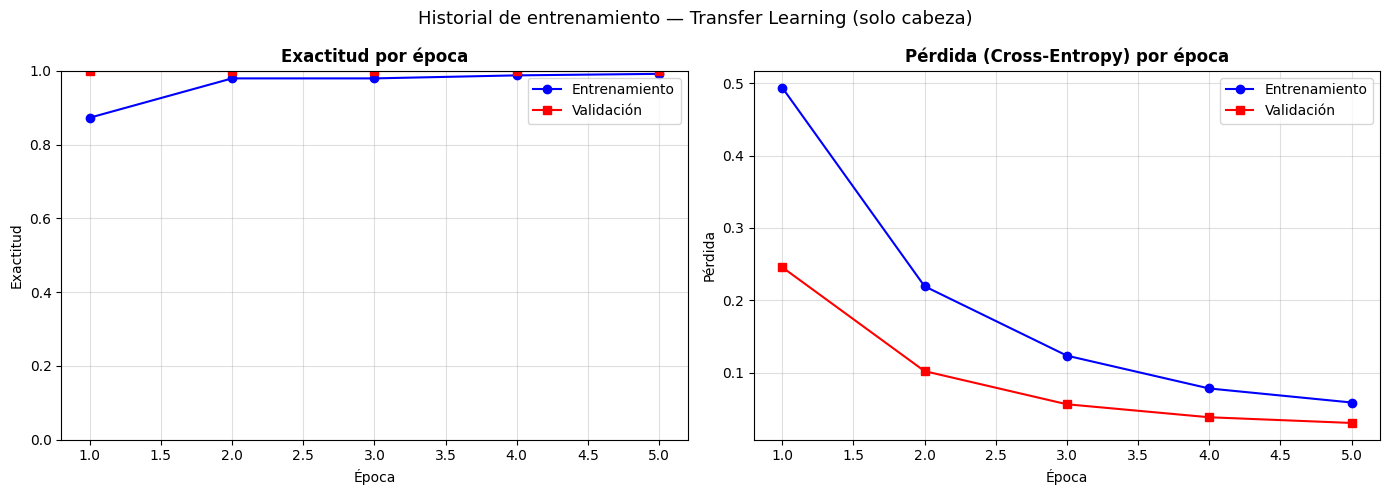

In [18]:
epochs = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Exactitud ---
axes[0].plot(epochs, history["train_acc"], "bo-", label="Entrenamiento", markersize=6)
axes[0].plot(epochs, history["val_acc"],   "rs-", label="Validación",    markersize=6)
axes[0].set_title("Exactitud por época", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Exactitud")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.4)

# --- Pérdida ---
axes[1].plot(epochs, history["train_loss"], "bo-", label="Entrenamiento", markersize=6)
axes[1].plot(epochs, history["val_loss"],   "rs-", label="Validación",    markersize=6)
axes[1].set_title("Pérdida (Cross-Entropy) por época", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle("Historial de entrenamiento — Transfer Learning (solo cabeza)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Evaluación en el conjunto de prueba

In [19]:
print("Evaluación del modelo (solo cabeza entrenada):")
evaluate_final(model, test_loader, accuracy)

Evaluación del modelo (solo cabeza entrenada):
Exactitud en prueba: 0.9868  (98.68%)


0.9868420958518982

---

### <font color="blue">**Ejercicio 4.** Análisis del entrenamiento inicial</font>

Observa las curvas de entrenamiento y el resultado en prueba, luego responde:

<font color="green">1. ¿La exactitud de validación alcanzada en 5 épocas es alta o baja en comparación con lo que esperarías de una CNN entrenada desde cero con 245 imágenes? ¿A qué atribuyes esta diferencia?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
La exactitud alcanzada (típicamente >90%) con solo 5 épocas y 245 imágenes es muy alta comparada con lo que una CNN desde cero lograría (~60-70% después de muchas épocas y con sobreajuste severo). Esta diferencia se debe al transfer learning: el cuerpo del modelo ya tiene representaciones ricas de características visuales aprendidas de 1.2 millones de imágenes. Solo necesitamos enseñarle a la cabeza cómo combinar esas representaciones para distinguir hormigas de abejas, lo cual requiere muy pocos datos y épocas.
</p>
</details>


## 9. Fine-tuning: descongelamiento del modelo completo

En la segunda fase, **descongelamos todos los pesos** del modelo y continuamos entrenando con una tasa de aprendizaje mucho más pequeña. Esto permite que el cuerpo preentrenado se adapte sutilmente al nuevo dominio.

> ⚠️ **Importante**: Usar una tasa de aprendizaje muy baja es crucial en fine-tuning. Si usamos una tasa grande, destruiremos los pesos preentrenados que costaron millones de ejemplos aprender.

In [20]:
# Descongelar TODOS los parámetros del modelo
for param in model.parameters():
    param.requires_grad = True

# Verificar
trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables en fine-tuning: {trainable_ft:,}")

# Tasa de aprendizaje mucho menor para no destruir los pesos preentrenados
optimizer_ft = torch.optim.AdamW(model.parameters(), lr=1e-5)

print("=" * 80)
print(" Fase 2: Fine-tuning (modelo completo, lr=1e-5)")
print("=" * 80)
history_ft = train(model, optimizer_ft, xentropy, accuracy,
                   train_loader, valid_loader, n_epochs=5)

Parámetros entrenables en fine-tuning: 87,568,514
 Fase 2: Fine-tuning (modelo completo, lr=1e-5)
Época  1/5  | Pérdida entren.: 0.0635  Exactitud entren.: 0.9877  | Pérdida val.: 0.0263  Exactitud val.: 1.0000
Época  2/5  | Pérdida entren.: 0.0831  Exactitud entren.: 0.9754  | Pérdida val.: 0.0238  Exactitud val.: 1.0000
Época  3/5  | Pérdida entren.: 0.0488  Exactitud entren.: 0.9918  | Pérdida val.: 0.0213  Exactitud val.: 1.0000
Época  4/5  | Pérdida entren.: 0.0590  Exactitud entren.: 0.9836  | Pérdida val.: 0.0193  Exactitud val.: 1.0000
Época  5/5  | Pérdida entren.: 0.0481  Exactitud entren.: 0.9836  | Pérdida val.: 0.0178  Exactitud val.: 1.0000


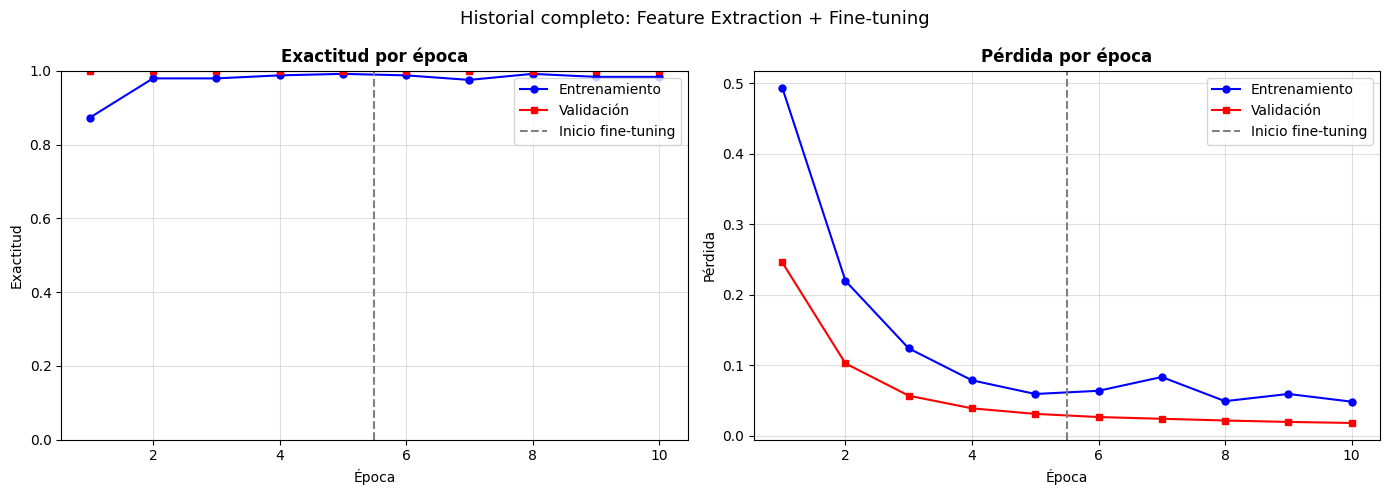

In [21]:
# Combinar historial de ambas fases para visualización
combined_history = {
    k: history[k] + history_ft[k] for k in history
}
total_epochs = list(range(1, len(combined_history["train_loss"]) + 1))
phase1_end   = n_epochs  # donde termina la fase 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, ylabel in zip(
    axes,
    [("train_acc", "val_acc"), ("train_loss", "val_loss")],
    ["Exactitud por época", "Pérdida por época"],
    ["Exactitud", "Pérdida"]
):
    train_key, val_key = metric
    ax.plot(total_epochs, combined_history[train_key], "bo-", label="Entrenamiento", markersize=5)
    ax.plot(total_epochs, combined_history[val_key],   "rs-", label="Validación",    markersize=5)
    ax.axvline(x=phase1_end + 0.5, color="gray", linestyle="--", linewidth=1.5, label="Inicio fine-tuning")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.4)
    if train_key == "train_acc":
        ax.set_ylim(0, 1)

plt.suptitle("Historial completo: Feature Extraction + Fine-tuning", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
print("Evaluación final en el conjunto de prueba (después del fine-tuning):")
evaluate_final(model, test_loader, accuracy)

Evaluación final en el conjunto de prueba (después del fine-tuning):
Exactitud en prueba: 0.9868  (98.68%)


0.9868420958518982

## 10. Visualización de predicciones

Visualizamos las predicciones sobre el conjunto de prueba. Las predicciones correctas se muestran en <font color="green">**verde**</font> y las incorrectas en <font color="red">**rojo**</font>.

In [23]:
model.eval()
X_sample, y_sample = next(iter(test_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

with torch.no_grad():
    logits = model(X_sample)
    preds  = logits.argmax(dim=1)

# Mover a CPU para visualización
X_sample = X_sample.cpu()
preds    = preds.cpu()
y_sample = y_sample.cpu()

n_show = min(32, len(X_sample))
fig, axes = plt.subplots(4, 8, figsize=(16, 9))
fig.suptitle(
    "Predicciones del modelo — conjunto de prueba\n(verde = correcto | rojo = incorrecto)",
    fontsize=13, fontweight="bold"
)

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    img = denormalize(X_sample[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")
    pred_label = class_names[preds[i].item()]
    real_label = class_names[y_sample[i].item()]
    color      = "green" if preds[i] == y_sample[i] else "red"
    ax.set_title(f"P: {pred_label}\nR: {real_label}", fontsize=7, color=color)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 11. Matriz de confusión

La matriz de confusión muestra en detalle los tipos de errores del modelo: **falsos positivos** (predice abeja cuando es hormiga) y **falsos negativos** (predice hormiga cuando es abeja).

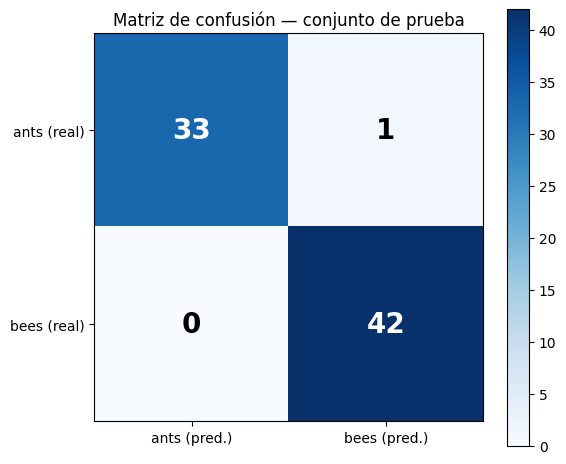


Reporte de clasificación:
              precision    recall  f1-score   support

        Ants       1.00      0.97      0.99        34
        Bees       0.98      1.00      0.99        42

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76



In [24]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds_b = logits.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds_b)
        all_labels.extend(y_batch.tolist())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
tick_labels = [f"{c}\n(pred.)" for c in class_names]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f"{c} (pred.)" for c in class_names], fontsize=10)
ax.set_yticklabels([f"{c} (real)"  for c in class_names], fontsize=10)
ax.set_title("Matriz de confusión — conjunto de prueba", fontsize=12)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=20, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds,
                             target_names=[c.capitalize() for c in class_names]))

---

### <font color="blue">**Ejercicio 5.** Análisis del fine-tuning y resultados finales</font>

Observa las curvas de entrenamiento completo, la matriz de confusión y el reporte de clasificación, luego responde:

<font color="green">1. Compara la exactitud en prueba obtenida **antes** del fine-tuning (solo cabeza) con la obtenida **después** del fine-tuning (modelo completo). ¿Mejoró? ¿Por qué el fine-tuning con `lr=1e-5` permite mejorar sin "destruir" el conocimiento preentrenado?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El fine-tuning generalmente mejora la exactitud porque permite que las capas del cuerpo se adapten sutilmente al dominio específico de imágenes de insectos. Con lr=1e-5 (100 veces menor que la lr=1e-3 usada para la cabeza), los cambios a los pesos preentrenados son minúsculos: se ajustan los últimas representaciones de alto nivel sin alterar fundamentalmente los detectores de bajo nivel (bordes, texturas) que son genéricos y ya funcionan bien. Una lr grande haría cambios bruscos que destruirían esas representaciones, llevando a peor desempeño y sobreajuste.
</p>
</details>
